In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.utils import to_categorical

In [3]:
train_data = pd.read_csv("digit.csv")
print("Shape of tarin_data:", train_data.shape)

X = train_data.iloc[:, 1:]
y = train_data.iloc[:, 0]

print("Shape of X after seperating feaures:", X.shape)

Shape of tarin_data: (42000, 785)
Shape of X after seperating feaures: (42000, 784)


In [4]:
# Check if X is not a pandas DataFrame
# If it is not, convert it into DataFrame 
# This ensures that DataFrme modules like .apply can be used sefty 
if not isinstance(X, pd.DataFrame):
    x = pd.DataFrame(x)

# Convert all values in X to nemeric type
# If any values cannot be converted, replace it with NaN
X = X.apply(pd.to_numeric, errors='coerce')

# Repalce all NaN (missing/invalid) values with 0 
# This prevents error during the model training 
X = X.fillna(0)

# Convert DataFrame to NumPy array
# Normalize pixel values from range(0-255) to (0-1)
# Neural networks train better with normalized inputs
X = X.values / 255.0

# Reshape the flattened image data into 28x28 format
# -1 automatically determines number of samples
# 28 = image height
# 28 = image width
# 1 = number of channels (grayscale image)
X = X.reshape(-1, 28, 28, 1)

print("Shape of X after reshaping: ", X.shape)

Shape of X after reshaping:  (42000, 28, 28, 1)


In [5]:
y = to_categorical(y, num_classes=10)
print("Shape of y after one-hot encoding: ", y.shape)

Shape of y after one-hot encoding:  (42000, 10)


In [6]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_tarin shape:", X_train.shape)

X_tarin shape: (33600, 28, 28, 1)


In [7]:
model = Sequential([
    Input(shape=(28, 28, 1)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9088 - loss: 0.3091 - val_accuracy: 0.9486 - val_loss: 0.1804
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9609 - loss: 0.1301 - val_accuracy: 0.9623 - val_loss: 0.1339
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9726 - loss: 0.0895 - val_accuracy: 0.9643 - val_loss: 0.1250
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9790 - loss: 0.0666 - val_accuracy: 0.9683 - val_loss: 0.1035
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9840 - loss: 0.0501 - val_accuracy: 0.9680 - val_loss: 0.1038
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9871 - loss: 0.0402 - val_accuracy: 0.9690 - val_loss: 0.1114
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9896 - loss: 0.0318 - val_accuracy: 0.9655 - val_loss: 0.1262
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9912 - loss: 0.0249 - 

In [9]:
# ================================
# Extract Final Accuracies
# ================================

train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
best_val_acc = max(history.history['val_accuracy'])

print("\n===== Final Results =====")
print(f"Final Training Accuracy     : {train_acc * 100:.2f}%")
print(f"Final Validation Accuracy   : {val_acc * 100:.2f}%")
print(f"Best Validation Accuracy    : {best_val_acc * 100:.2f}%")

# ================================
# Print Accuracy Per Epoch
# ================================

print("\n===== Accuracy Per Epoch =====")
for epoch in range(len(history.history['accuracy'])):
    print(f"Epoch {epoch+1}: "
          f"Train Acc = {history.history['accuracy'][epoch]*100:.2f}% | "
          f"Val Acc = {history.history['val_accuracy'][epoch]*100:.2f}%")


===== Final Results =====
Final Training Accuracy     : 99.39%
Final Validation Accuracy   : 97.24%
Best Validation Accuracy    : 97.24%

===== Accuracy Per Epoch =====
Epoch 1: Train Acc = 90.88% | Val Acc = 94.86%
Epoch 2: Train Acc = 96.09% | Val Acc = 96.23%
Epoch 3: Train Acc = 97.26% | Val Acc = 96.43%
Epoch 4: Train Acc = 97.90% | Val Acc = 96.83%
Epoch 5: Train Acc = 98.40% | Val Acc = 96.80%
Epoch 6: Train Acc = 98.71% | Val Acc = 96.90%
Epoch 7: Train Acc = 98.96% | Val Acc = 96.55%
Epoch 8: Train Acc = 99.12% | Val Acc = 97.12%
Epoch 9: Train Acc = 99.28% | Val Acc = 96.95%
Epoch 10: Train Acc = 99.39% | Val Acc = 97.24%


263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9724 - loss: 0.1176
Valudation Accuracy: 97.24%


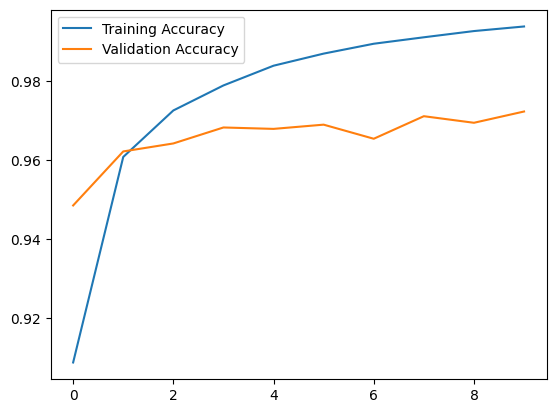

In [10]:
val_loss, val_acccuracy = model.evaluate(X_val, y_val)
print(f"Valudation Accuracy: {val_acccuracy * 100:.2f}%")
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


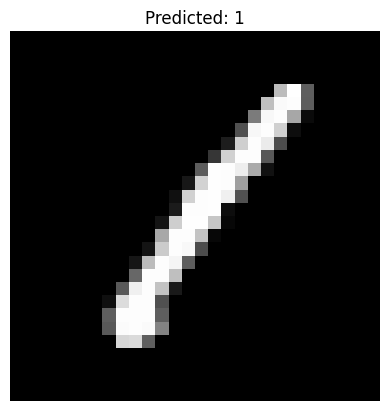

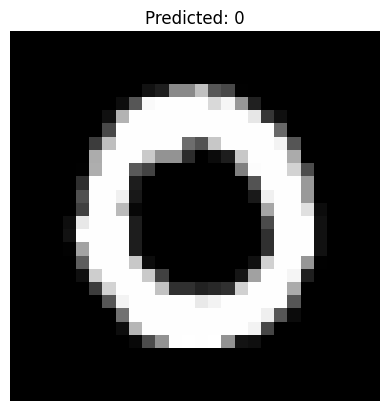

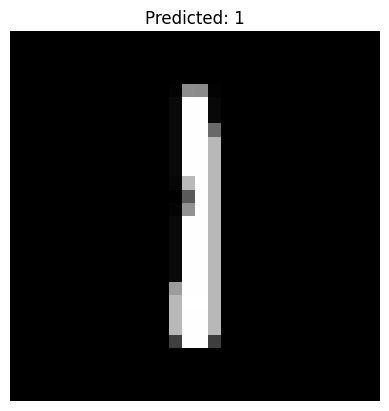

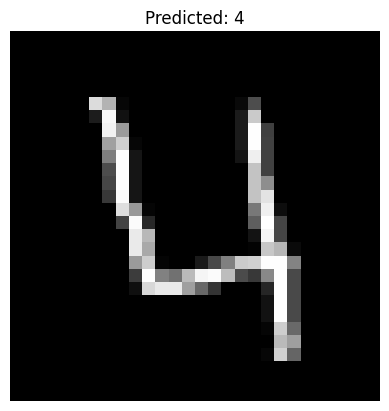

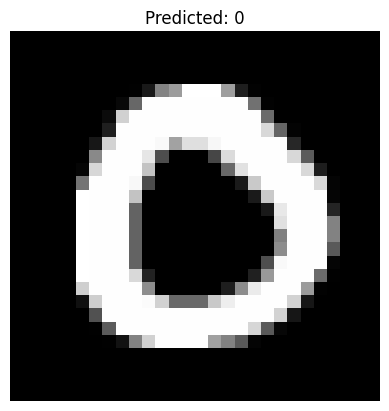

In [11]:
# Load the dataset
test_data = pd.read_csv('digit.csv')

# Remove label column (first column)
X_test = test_data.iloc[:, 1:].values / 255.0  

# Reshape to (samples, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Make predictions
predictions = model.predict(X_test)

# Get predicted digit (highest probability index)
predicted_labels = np.argmax(predictions, axis=1)

# Show first 5 predictions
for i in range(5):
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {predicted_labels[i]}")
    plt.axis('off')
    plt.show()

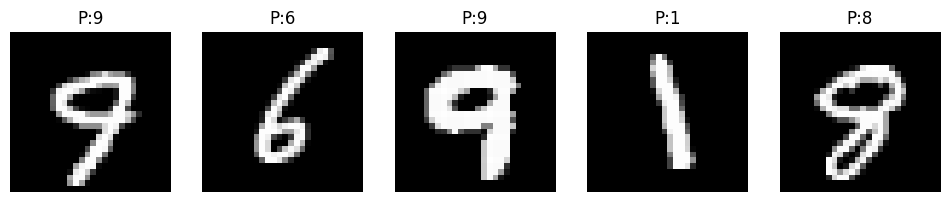

In [12]:
random_indices = np.random.choice(len(X_test), 5, replace=False)

plt.figure(figsize=(12,3))

for idx, i in enumerate(random_indices):
    plt.subplot(1, 5, idx+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"P:{predicted_labels[i]}")
    plt.axis('off')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step


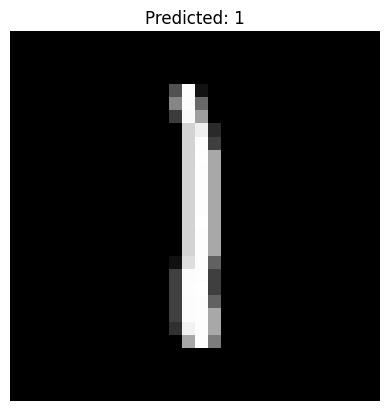

In [13]:
def show_image(index):
    # Get image
    image = X_test[index]
    
    # Predict digit
    prediction = model.predict(image.reshape(1, 28, 28, 1))
    predicted_label = np.argmax(prediction)
    
    # Show image
    plt.imshow(image.reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {predicted_label}")
    plt.axis('off')
    plt.show()

show_image(1000)

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


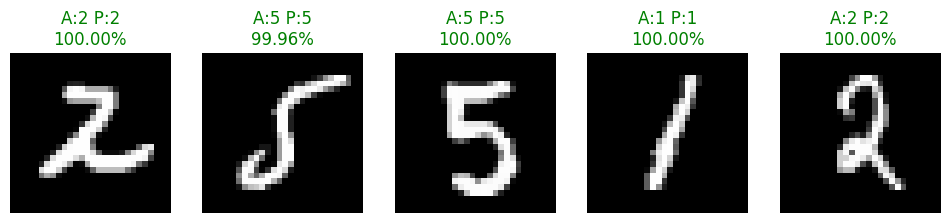

Total Wrong Predictions: 382


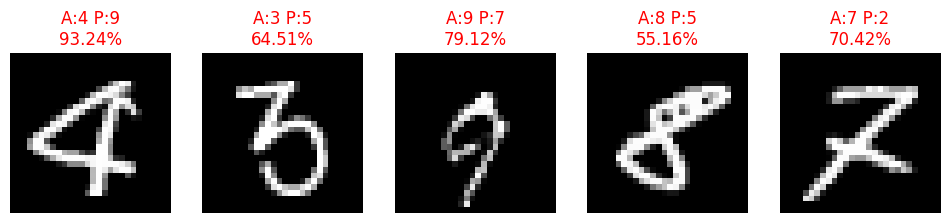

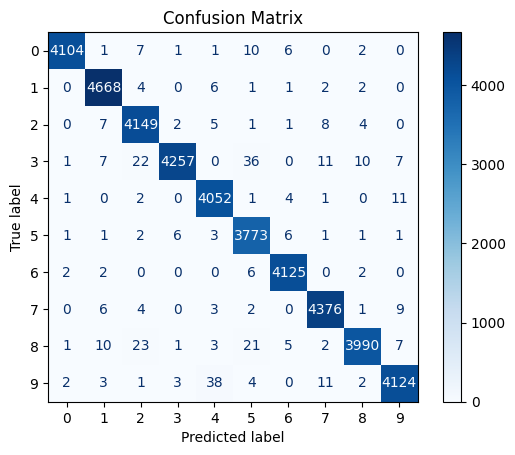

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get actual labels
y_test = test_data.iloc[:, 0].values

# Get model predictions
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

# =========================
# 1️⃣ Show Random Predictions
# =========================

random_indices = np.random.choice(len(X_test), 5, replace=False)

plt.figure(figsize=(12,3))

for idx, i in enumerate(random_indices):
    plt.subplot(1, 5, idx+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    
    confidence = np.max(predictions[i]) * 100
    
    if predicted_labels[i] == y_test[i]:
        color = "green"
    else:
        color = "red"
        
    plt.title(f"A:{y_test[i]} P:{predicted_labels[i]}\n{confidence:.2f}%", color=color)
    plt.axis('off')

plt.show()


# =========================
# 2️⃣ Show Only Wrong Predictions
# =========================

wrong_indices = np.where(predicted_labels != y_test)[0]

print(f"Total Wrong Predictions: {len(wrong_indices)}")

if len(wrong_indices) > 0:
    plt.figure(figsize=(12,3))
    
    for idx, i in enumerate(wrong_indices[:5]):  # show first 5 wrong
        plt.subplot(1, 5, idx+1)
        plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
        
        confidence = np.max(predictions[i]) * 100
        
        plt.title(f"A:{y_test[i]} P:{predicted_labels[i]}\n{confidence:.2f}%", color="red")
        plt.axis('off')
    
    plt.show()


# =========================
# 3️⃣ Confusion Matrix
# =========================

cm = confusion_matrix(y_test, predicted_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [15]:
import cv2
import numpy as np

drawing = False

img = np.ones((400,400,3),dtype=np.uint8)*255

def draw(event,x,y,flags,param):
    global drawing
    
    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
        
    elif event == cv2.EVENT_MOUSEMOVE:
        if drawing:
            cv2.circle(img,(x,y),8,(0,0,0),-1)
            
    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False

cv2.namedWindow("Draw")
cv2.setMouseCallback("Draw", draw)

while True:

    cv2.imshow("Draw",img)

    if cv2.waitKey(1) == 27:
        break

cv2.destroyAllWindows()

In [20]:
import cv2
import numpy as np

drawing = False
predicted_digit = ""

canvas_size = 400
img = np.ones((canvas_size, canvas_size), dtype=np.uint8) * 255


# -----------------------------
# preprocess digit (crop + center)
# -----------------------------
def preprocess_digit(img):

    digit = 255 - img

    _, thresh = cv2.threshold(digit, 50, 255, cv2.THRESH_BINARY)

    coords = cv2.findNonZero(thresh)

    if coords is None:
        return None

    x, y, w, h = cv2.boundingRect(coords)

    digit = digit[y:y+h, x:x+w]

    digit = cv2.resize(digit, (28,28))

    digit = digit / 255.0

    digit = digit.reshape(1,28,28,1)

    return digit


# -----------------------------
# prediction
# -----------------------------
def predict_digit():
    global predicted_digit

    digit = preprocess_digit(img)

    if digit is None:
        predicted_digit = ""
        return

    prediction = model.predict(digit, verbose=0)

    predicted_digit = str(np.argmax(prediction))


# -----------------------------
# drawing handler
# -----------------------------
def draw(event, x, y, flags, param):

    global drawing, img, predicted_digit

    if event == cv2.EVENT_LBUTTONDOWN:

        # restart button click
        if 10 <= x <= 120 and 10 <= y <= 50:
            img[:] = 255
            predicted_digit = ""
            return

        drawing = True

    elif event == cv2.EVENT_MOUSEMOVE:
        if drawing:
            cv2.circle(img, (x,y), 15, (0), -1)

    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False
        predict_digit()


# -----------------------------
# window
# -----------------------------
cv2.namedWindow("Digit Predictor")
cv2.setMouseCallback("Digit Predictor", draw)


while True:

    display = cv2.cvtColor(img.copy(), cv2.COLOR_GRAY2BGR)

    # restart button
    cv2.rectangle(display, (10,10), (120,50), (200,200,200), -1)
    cv2.putText(display, "Restart",
                (20,40),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0,0,0),
                2)

    # prediction text
    cv2.putText(display,
                f"Prediction: {predicted_digit}",
                (150,40),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.9,
                (0,0,0),
                2)

    cv2.imshow("Digit Predictor", display)

    if cv2.waitKey(1) == 27:
        break


cv2.destroyAllWindows()